# Анализ финансирования стартапов

**Python | Pandas | Matplotlib | Seaborn | EDA**

---


Автор: Девичева Мария Станиславовна

## Описание проекта

---

Проект посвящён исследованию рынка стартапов и структуры их финансирования.  
Цель анализа — определить перспективный сегмент рынка и подходящий тип финансирования с позиции инвестора на **2015 год**.

В рамках проекта выполнены:

- первичная диагностика и предобработка данных;
- очистка пропусков, обработка дубликатов и преобразование типов;
- анализ сроков и этапов финансирования компаний;
- сегментация рынков по масштабу распространённости;
- поиск аномальных значений методом IQR;
- исследование популярности и объёма типов финансирования;
- анализ годовой динамики раундов и общего объёма инвестиций;
- анализ возвратов по типам финансирования;
- подготовка итоговой инвестиционной рекомендации.

**Ключевой результат проекта:**  
в качестве наиболее перспективного направления для дальнейшего анализа выделено сочетание **Medical + venture**.

Проект демонстрирует навыки предобработки данных, исследовательского анализа, визуализации, работы с выбросами и подготовки бизнес-ориентированных аналитических выводов.

# Введение

Стартапы являются одним из ключевых источников инноваций и экономического развития. Для их роста необходимы инвестиции, которые могут предоставляться в различных формах: от посевного финансирования до крупных венчурных и частных инвестиций. Анализ информации о финансировании стартапов позволяет выявить закономерности инвестиционной активности, определить наиболее перспективные отрасли и оценить эффективность различных типов финансирования.

**Цель данного проекта** — провести исследовательский анализ данных о стартапах и их финансировании. В рамках работы будут выполнены предобработка данных, создание новых признаков, анализ распределения финансирования, выявление аномальных значений, исследование динамики инвестиций по годам, а также анализ возврата средств по различным типам финансирования.

По итогам исследования планируется определить наиболее перспективные направления для инвестирования и подобрать наиболее подходящий тип финансирования, который можно рекомендовать потенциальному инвестору по состоянию на 2015 год.


## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации


In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
df = pd.read_csv(
    'https://code.s3.yandex.net/datasets/cb_investments.zip',
    sep=';',
    low_memory=False
)

initial_rows = len(df)

In [117]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [118]:
df.shape

(54294, 40)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [120]:
df.describe()

,funding_rounds,participants,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
count,49438.000000,30473.000000,38554.000000,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,...,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04
mean,1.696205,1.451646,2007.094231,2.173215e+05,7.501051e+06,6.163322e+03,1.302213e+05,2.336410e+04,1.888157e+06,6.541898e+04,...,3.845592e+04,7.074227e+03,1.243955e+06,1.492891e+06,1.205356e+06,7.375261e+05,3.424682e+05,1.697692e+05,5.767067e+04,1.423197e+04
std,1.294213,2.022233,9.862177,1.056985e+06,2.847112e+07,1.999048e+05,2.981404e+06,1.432046e+06,1.382046e+08,6.582908e+05,...,3.864461e+06,4.282166e+05,5.531974e+06,7.472704e+06,7.993592e+06,9.815218e+06,5.406915e+06,6.277905e+06,5.252312e+06,2.716865e+06
min,1.000000,0.000000,1636.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000,0.000000,2005.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000,1.000000,2010.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.000000,2.000000,2012.000000,2.500000e+04,5.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,18.000000,36.000000,2014.000000,1.300000e+08,2.351000e+09,2.500000e+07,2.924328e+08,3.000000e+08,3.007950e+10,6.359026e+07,...,6.806116e+08,7.200000e+07,3.190000e+08,5.420000e+08,4.900000e+08,1.200000e+09,4.000000e+08,1.060000e+09,1.000000e+09,6.000000e+08


In [121]:
df.isna().sum().sort_values(ascending=False)

,0
state_code,24133
mid_funding_at,24006
participants,23821
founded_quarter,15812
founded_month,15812
founded_year,15740
founded_at,15740
city,10972
country_code,10129
region,10129


In [122]:
df.duplicated().sum()

np.int64(4855)

# Вывод по основному датасету

В исходном датасете 54 294 строки и 40 столбцов. В данных присутствуют пропуски, в том числе в признаках рынка, датах и суммах финансирования, а также 4 855 полных дубликатов. Столбец `funding_total_usd` изначально имеет строковый тип и требует преобразования в числовой формат. Перед аналитической частью необходимо удалить дубликаты, обработать пропуски и привести даты и суммы к корректным типам.

In [123]:
returns = pd.read_csv(
    'https://code.s3.yandex.net/datasets/cb_returns.csv'
)

In [124]:
returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [125]:
returns.shape

(15, 14)

In [126]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [127]:
returns.describe()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.0,15.000000,15.000000,15.000000,15.000000,15.000000
mean,2007.000000,158.816000,2705.241333,0.255333,48.725333,2.319333,315.656667,100.615333,0.0,239.155333,73.664000,6.068667,0.346667,0.124000
std,4.472136,180.020855,2206.926388,0.391825,27.826630,2.496527,345.365979,95.502534,0.0,324.392213,86.990707,12.483043,0.296303,0.208286
min,2000.000000,2.880000,23.490000,0.000000,9.400000,0.000000,1.090000,1.180000,0.0,0.000000,0.340000,0.000000,0.050000,0.000000
25%,2003.500000,13.315000,394.880000,0.000000,29.480000,0.015000,11.105000,7.805000,0.0,1.905000,2.745000,0.000000,0.120000,0.000000
50%,2007.000000,70.410000,2717.020000,0.030000,46.740000,1.780000,125.680000,97.210000,0.0,88.810000,24.360000,0.000000,0.200000,0.000000
75%,2010.500000,291.310000,3752.375000,0.345000,65.200000,3.590000,538.325000,168.340000,0.0,361.545000,122.365000,1.520000,0.510000,0.250000
max,2014.000000,530.750000,7272.010000,1.150000,105.720000,7.870000,1017.750000,293.980000,0.0,988.530000,262.700000,37.200000,1.030000,0.720000


In [128]:
returns.isna().sum()

,0
year,0
seed,0
venture,0
equity_crowdfunding,0
undisclosed,0
convertible_note,0
debt_financing,0
angel,0
grant,0
private_equity,0


In [129]:
returns.duplicated().sum()

np.int64(0)

# Вывод по дополнительному датасету

Дополнительный датасет содержит 15 наблюдений — по одному на каждый год с 2000 по 2014 — и показатели возвратов по 13 типам финансирования. Пропусков и дубликатов нет, числовые признаки уже представлены в подходящем формате. После загрузки `year` используется как индекс.

# 1.2 Предобработка данных

В данном разделе проверим названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведем их к единому аккуратному стилю.

In [130]:
df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [131]:
df.columns = df.columns.str.strip()
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [132]:
df['funding_total_usd'] = (
    df['funding_total_usd']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

In [133]:
df['funding_total_usd'].head()

,funding_total_usd
0,90000000.0
1,2000000.0
2,9000000.0
3,7700000.0
4,540000.0


In [134]:
df['funding_total_usd'].dtype

dtype('float64')

In [135]:
date_columns = [
    'founded_at',
    'founded_month',
    'first_funding_at',
    'mid_funding_at',
    'last_funding_at'
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors='coerce',
        format='mixed'
    )

In [136]:
df[date_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   founded_at        38553 non-null  datetime64[ns]
 1   founded_month     38482 non-null  datetime64[ns]
 2   first_funding_at  49428 non-null  datetime64[ns]
 3   mid_funding_at    30288 non-null  datetime64[ns]
 4   last_funding_at   49432 non-null  datetime64[ns]
dtypes: datetime64[ns](5)
memory usage: 2.1 MB


In [137]:
returns.set_index('year', inplace=True)

returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [138]:
text_columns = df.select_dtypes(include='object').columns

text_columns

Index(['name', 'homepage_url', 'category_list', 'market', 'status',
       'country_code', 'state_code', 'region', 'city', 'founded_quarter'],
      dtype='object')

In [139]:
df[text_columns].isna().sum()

,0
name,4857
homepage_url,8305
category_list,8817
market,8817
status,6170
country_code,10129
state_code,24133
region,10129
city,10972
founded_quarter,15812


In [140]:
# Заполняем пропуски и удаляем пробелы по краям строк
df[text_columns] = (
    df[text_columns]
    .fillna('unknown')
    .apply(lambda column: column.str.strip())
)

In [141]:
df[df['market'].str.contains(
    r'^\s*Software\s*$',
    na=False
)][['market']].value_counts()

,count
market,
Software,5489


In [142]:
df.loc[
    df['market'].str.contains('software', case=False, na=False),
    'market'
].sort_values().unique()

array(['Embedded Hardware and Software', 'Enterprise Software',
       'Hardware + Software', 'Mobile Software Tools',
       'Productivity Software', 'Software'], dtype=object)

In [143]:
df[text_columns].isna().sum()

,0
name,0
homepage_url,0
category_list,0
market,0
status,0
country_code,0
state_code,0
region,0
city,0
founded_quarter,0


In [144]:
print('Количество дубликатов до удаления:', df.duplicated().sum())

Количество дубликатов до удаления: 4855


In [145]:
df = df.drop_duplicates()

print('Количество дубликатов после удаления:', df.duplicated().sum())

Количество дубликатов после удаления: 0


In [146]:
print('Пропусков в funding_total_usd:', df['funding_total_usd'].isna().sum())
print('Нулевых значений в funding_total_usd:', (df['funding_total_usd'] == 0).sum())

Пропусков в funding_total_usd: 8532
Нулевых значений в funding_total_usd: 0


In [147]:
rows_before_funding_cleaning = len(df)

df = df.dropna(subset=['funding_total_usd'])
df = df[df['funding_total_usd'] > 0]

rows_after_funding_cleaning = len(df)

print(f'Удалено строк без данных о финансировании: {rows_before_funding_cleaning - rows_after_funding_cleaning}')
print(f'Осталось строк: {rows_after_funding_cleaning}')

Удалено строк без данных о финансировании: 8532
Осталось строк: 40907


In [148]:
print('Пропусков в funding_total_usd после обработки:', df['funding_total_usd'].isna().sum())
print('Нулевых значений после обработки:', (df['funding_total_usd'] == 0).sum())

Пропусков в funding_total_usd после обработки: 0
Нулевых значений после обработки: 0


Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

Оценим размер оставшихся пропусков в столбце.

In [149]:
print('Пропусков в mid_funding_at до заполнения:', df['mid_funding_at'].isna().sum())

Пропусков в mid_funding_at до заполнения: 13676


In [150]:
df['mid_funding_at'] = df['mid_funding_at'].fillna(
    df['first_funding_at'] +
    (df['last_funding_at'] - df['first_funding_at']) / 2
)

In [151]:
print('Пропусков в mid_funding_at после заполнения:', df['mid_funding_at'].isna().sum())

Пропусков в mid_funding_at после заполнения: 1


In [152]:
df[df['mid_funding_at'].isna()][
    [
        'name',
        'first_funding_at',
        'mid_funding_at',
        'last_funding_at',
        'funding_rounds',
        'funding_total_usd'
    ]
]

,name,first_funding_at,mid_funding_at,last_funding_at,funding_rounds,funding_total_usd
33041,Nubank,NaT,NaT,2014-09-25,2.0,16300000.0


In [153]:
df = df.dropna(subset=['mid_funding_at']).copy()

In [154]:
df['mid_funding_at'].isna().sum()

np.int64(0)

In [155]:
final_rows = len(df)

Оценим полноту данных и сделаем предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [156]:
final_rows = len(df)

removed = initial_rows - final_rows
removed_percent = removed / initial_rows * 100

print(f'Было строк: {initial_rows}')
print(f'Осталось строк: {final_rows}')
print(f'Удалено строк: {removed}')
print(f'Процент удалённых данных: {removed_percent:.2f}%')

Было строк: 54294
Осталось строк: 40906
Удалено строк: 13388
Процент удалённых данных: 24.66%


# Вывод

После предобработки было удалено около четверти исходных данных. Основная часть исключённых записей приходилась на полные дубликаты и компании без информации о финансировании, которые нельзя было использовать в дальнейшем анализе.

После очистки в датасете осталось более 40 тысяч наблюдений. Этого объёма достаточно для дальнейшего описательного и сравнительного анализа. При этом сам размер выборки не гарантирует её полной репрезентативности, поэтому ограничения исходных данных необходимо учитывать при интерпретации результатов.


## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.


In [157]:
# Проверим нужные столбцы
df[['funding_rounds', 'first_funding_at', 'last_funding_at', 'funding_total_usd']].head()

,funding_rounds,first_funding_at,last_funding_at,funding_total_usd
0,1.0,2014-01-06,2014-01-06,90000000.0
1,1.0,2014-05-15,2014-05-15,2000000.0
2,1.0,2009-07-02,2009-07-02,9000000.0
3,3.0,2013-11-21,2014-11-03,7700000.0
4,1.0,2014-01-14,2014-01-14,540000.0


In [158]:
# Создадим разницу между первым и последним финансированием в днях
df['funding_period_days'] = (
    df['last_funding_at'] - df['first_funding_at']
).dt.days

In [159]:
# Функция для разделения компаний на группы
def funding_period_group(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_period_days'] <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

In [160]:
df['funding_period_group'] = df.apply(funding_period_group, axis=1)

In [161]:
df['funding_period_group'].value_counts(normalize=True) * 100

,proportion
funding_period_group,
Единичное финансирование,58.947343
Срок финансирования более года,30.049382
Срок финансирования до года,11.003276


In [162]:
group_order = [
    'Единичное финансирование',
    'Срок финансирования до года',
    'Срок финансирования более года'
]

palette = {
    'Единичное финансирование': '#66c2a5',
    'Срок финансирования до года': '#fc8d62',
    'Срок финансирования более года': '#8da0cb'
}

In [163]:
company_share = (
    df['funding_period_group']
    .value_counts(normalize=True)
    .reindex(group_order)
    * 100
)

company_share

,proportion
funding_period_group,
Единичное финансирование,58.947343
Срок финансирования до года,11.003276
Срок финансирования более года,30.049382


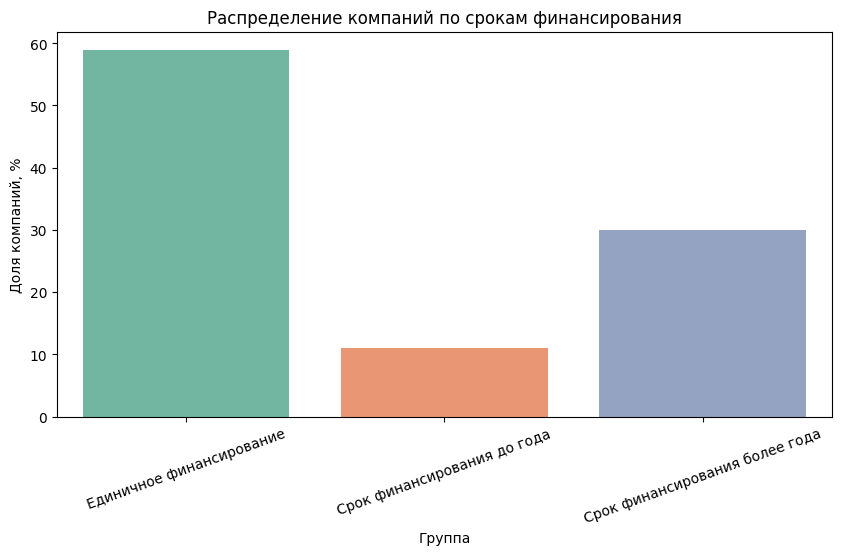

In [164]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=company_share.index,
    y=company_share.values,
    hue=company_share.index,
    palette=palette,
    legend=False
)

plt.title('Распределение компаний по срокам финансирования')
plt.ylabel('Доля компаний, %')
plt.xlabel('Группа')
plt.xticks(rotation=20)

plt.show()

In [165]:
investment_share = (
    df.groupby('funding_period_group')['funding_total_usd']
    .sum()
    .reindex(group_order)
)

investment_share = investment_share / investment_share.sum() * 100

investment_share

,funding_total_usd
funding_period_group,
Единичное финансирование,30.619004
Срок финансирования до года,7.510320
Срок финансирования более года,61.870676


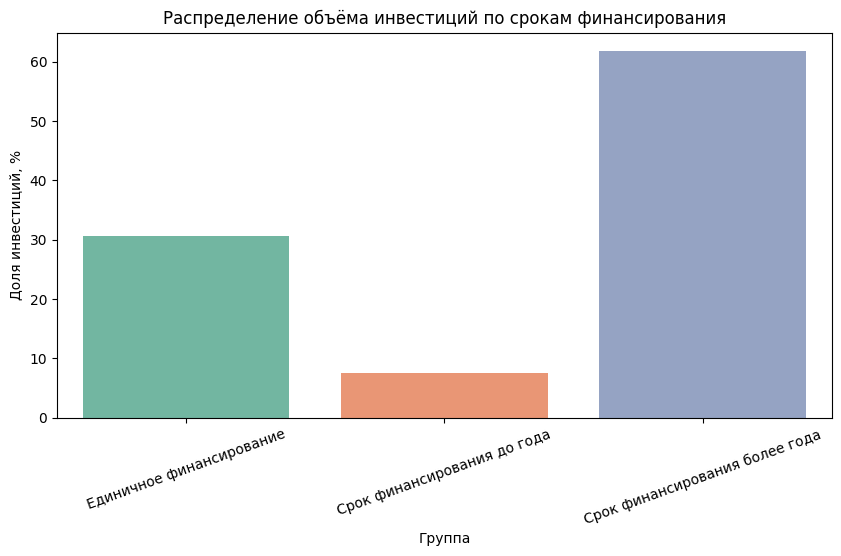

In [166]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=investment_share.index,
    y=investment_share.values,
    hue=investment_share.index,
    palette=palette,
    legend=False
)

plt.title('Распределение объёма инвестиций по срокам финансирования')
plt.ylabel('Доля инвестиций, %')
plt.xlabel('Группа')
plt.xticks(rotation=20)

plt.show()

# Вывод

Большинство компаний — около 58,9% — получили только один раунд финансирования. При этом на компании, у которых период между первым и последним финансированием превышал один год, приходится около 61,9% общего объёма привлечённых средств, хотя их доля составляет примерно 30,0% компаний.

Таким образом, более продолжительный период финансирования связан с существенно большей долей привлечённого капитала. Однако по этим данным нельзя напрямую делать вывод об успешности компаний: продолжительность финансирования здесь выступает только как наблюдаемый признак.


### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце market. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.


In [167]:
# Посчитаем количество компаний в каждом сегменте рынка
market_counts = df['market'].value_counts()

market_counts.head()

,count
market,
Software,4812
Biotechnology,3590
unknown,2503
Mobile,2344
E-Commerce,1866


In [168]:
# Функция для классификации сегментов
def market_size_group(count):
    if count > 120:
        return 'mass'
    elif count >= 35:
        return 'mid'
    else:
        return 'niche'

In [169]:
market_groups = market_counts.apply(market_size_group)

segment_counts = (
    market_groups
    .value_counts()
    .reindex(['mass', 'mid', 'niche'])
)

segment_counts

,count
count,
mass,49
mid,57
niche,289


In [170]:
print('Массовых сегментов:', segment_counts['mass'])
print('Средних сегментов:', segment_counts['mid'])
print('Нишевых сегментов:', segment_counts['niche'])

Массовых сегментов: 49
Средних сегментов: 57
Нишевых сегментов: 289


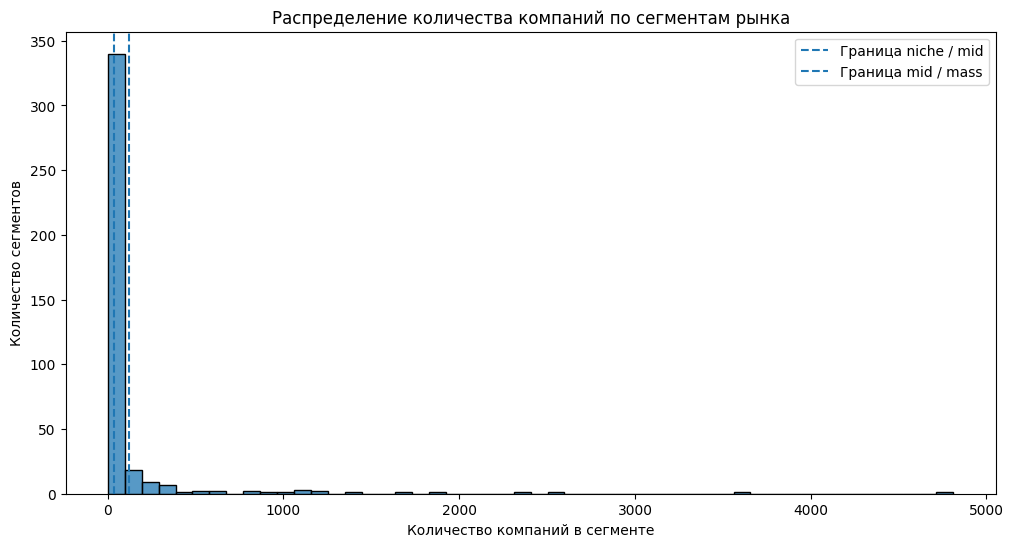

In [171]:
plt.figure(figsize=(12, 6))

sns.histplot(market_counts, bins=50)

plt.axvline(35, linestyle='--', label='Граница niche / mid')
plt.axvline(120, linestyle='--', label='Граница mid / mass')

plt.title('Распределение количества компаний по сегментам рынка')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.legend()
plt.show()

In [172]:
segment_share = segment_counts / segment_counts.sum() * 100

segment_share

,count
count,
mass,12.405063
mid,14.430380
niche,73.164557


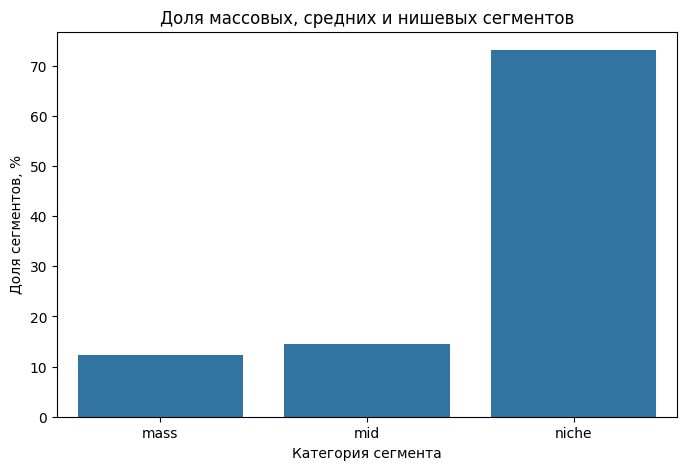

In [173]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_share.index,
    y=segment_share.values
)

plt.title('Доля массовых, средних и нишевых сегментов')
plt.xlabel('Категория сегмента')
plt.ylabel('Доля сегментов, %')
plt.show()

In [174]:
market_group_map = market_groups.to_dict()

df['market_group'] = df['market'].map(market_group_map)

In [175]:
company_market_share = (
    df['market_group']
    .value_counts(normalize=True)
    .reindex(['mass', 'mid', 'niche'])
    * 100
)

company_market_share

,proportion
market_group,
mass,88.583582
mid,9.387376
niche,2.029042


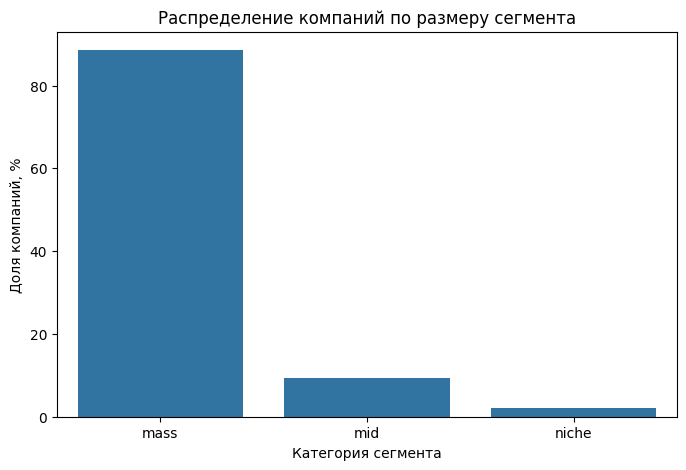

In [176]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=company_market_share.index,
    y=company_market_share.values
)

plt.title('Распределение компаний по размеру сегмента')
plt.xlabel('Категория сегмента')
plt.ylabel('Доля компаний, %')
plt.show()

In [177]:
for group in ['mass', 'mid', 'niche']:
    print(
        f'{group}: '
        f'{segment_share[group]:.1f}% сегментов, '
        f'{company_market_share[group]:.1f}% компаний'
    )

mass: 12.4% сегментов, 88.6% компаний
mid: 14.4% сегментов, 9.4% компаний
niche: 73.2% сегментов, 2.0% компаний


# Вывод

После очистки текстовых данных в датасете выделено 49 массовых, 57 средних и 289 нишевых сегментов рынка.

Рынок стартапов имеет ярко выраженную фрагментированную структуру. Большинство уникальных направлений относится к нишевым сегментам, однако основная часть компаний сосредоточена в небольшом количестве массовых рынков. Это говорит о том, что новые проекты появляются в самых разных специализированных областях, однако только часть из них развивается до крупных массовых отраслей.

Для дальнейшего анализа средние сегменты объединены в категорию `mid`, нишевые — в категорию `niche`, а массовые сегменты сохранены под своими исходными названиями.

### 2.3. Объединение средних и нишевых сегментов

Оставим в столбце `market` названия только массовых сегментов. Все средние сегменты объединим в категорию `mid`, а нишевые — в `niche`. Дальнейший анализ будет выполняться с учётом этого преобразования.


In [178]:
def replace_market(market):
    group = market_group_map[market]

    if group == 'mass':
        return market

    return group


df['market'] = df['market'].apply(replace_market)

df['market'].value_counts().head(30)


,count
market,
Software,4812
mid,3840
Biotechnology,3590
unknown,2503
Mobile,2344
E-Commerce,1866
Curated Web,1693
Enterprise Software,1381
Health Care,1185


In [179]:
df = df.drop(columns='market_group')
df[['market']].head()


,market
0,Education
1,unknown
2,mid
3,Education
4,Education


#### Вывод

В столбце `market` сохранены названия массовых сегментов рынка. Все средние сегменты объединены в категорию `mid`, а нишевые — в категорию `niche`. Это уменьшает влияние большого числа малочисленных категорий и позволяет анализировать их как две укрупнённые группы.


## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов
Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу funding_total_usd графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажим интервал, в котором лежат типичные значения.

In [180]:
df['funding_total_usd'].describe()


,funding_total_usd
count,4.090600e+04
mean,1.591252e+07
std,1.686809e+08
min,1.000000e+00
25%,3.500000e+05
50%,2.000000e+06
75%,1.000000e+07
max,3.007950e+10


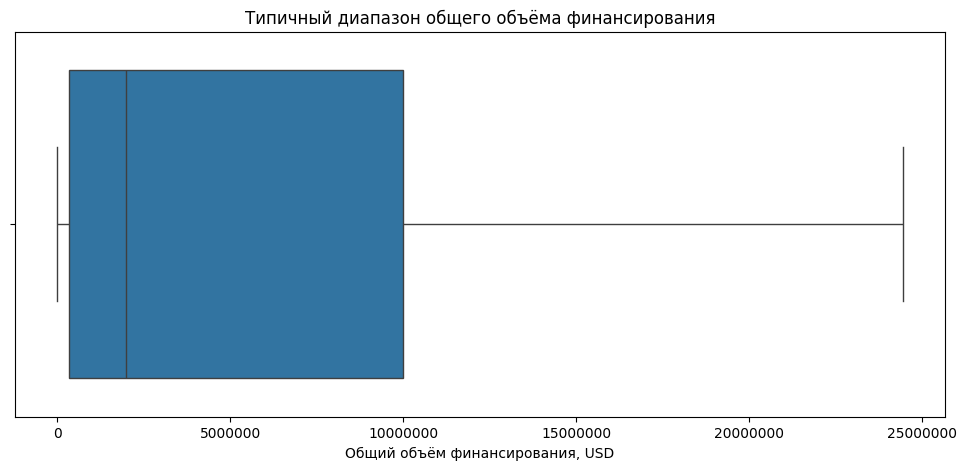

In [181]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df['funding_total_usd'],
    showfliers=False
)

plt.title('Типичный диапазон общего объёма финансирования')
plt.xlabel('Общий объём финансирования, USD')
plt.ticklabel_format(style='plain', axis='x')
plt.show()


In [182]:
q1 = df['funding_total_usd'].quantile(0.25)
q3 = df['funding_total_usd'].quantile(0.75)
iqr = q3 - q1

lower_bound = max(0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr

print(f'Первый квартиль: {q1:,.0f} USD')
print(f'Третий квартиль: {q3:,.0f} USD')
print(
    f'Типичный диапазон по методу IQR: '
    f'от {lower_bound:,.0f} до {upper_bound:,.0f} USD'
)


Первый квартиль: 350,000 USD
Третий квартиль: 10,000,000 USD
Типичный диапазон по методу IQR: от 0 до 24,475,000 USD


По boxplot верхняя граница типичных значений находится примерно на уровне 25 млн долларов. Значения выше этой области можно рассматривать как потенциально аномальные. Для дальнейшего анализа границы выбросов рассчитываются отдельно в каждом сегменте.


In [183]:
def mark_outliers_by_iqr(data, group_col, value_col):
    result = data.copy()
    result['is_outlier'] = False

    for group in result[group_col].dropna().unique():
        group_data = result[result[group_col] == group]

        q1 = group_data[value_col].quantile(0.25)
        q3 = group_data[value_col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        mask = (
            (result[group_col] == group)
            & (
                (result[value_col] < lower_bound)
                | (result[value_col] > upper_bound)
            )
        )

        result.loc[mask, 'is_outlier'] = True

    return result

In [184]:
df = mark_outliers_by_iqr(
    df,
    group_col='market',
    value_col='funding_total_usd'
)

In [185]:
df['is_outlier'].value_counts()

,count
is_outlier,
False,35662
True,5244


In [186]:
df['is_outlier'].value_counts(normalize=True) * 100

,proportion
is_outlier,
False,87.180365
True,12.819635


In [187]:
outlier_share_by_market = (
    df.groupby('market')['is_outlier']
    .agg(['sum', 'count'])
)

outlier_share_by_market['outlier_share'] = (
    outlier_share_by_market['sum']
    / outlier_share_by_market['count']
    * 100
)

outlier_share_by_market = (
    outlier_share_by_market
    .sort_values('outlier_share', ascending=False)
)

outlier_share_by_market.head(10)


,sum,count,outlier_share
market,,,
Real Estate,48,279,17.204301
Entertainment,25,150,16.666667
Consulting,58,349,16.618911
Search,48,291,16.494845
Cloud Computing,25,152,16.447368
Photography,33,204,16.176471
SaaS,44,272,16.176471
Technology,38,238,15.966387
Video,30,188,15.957447


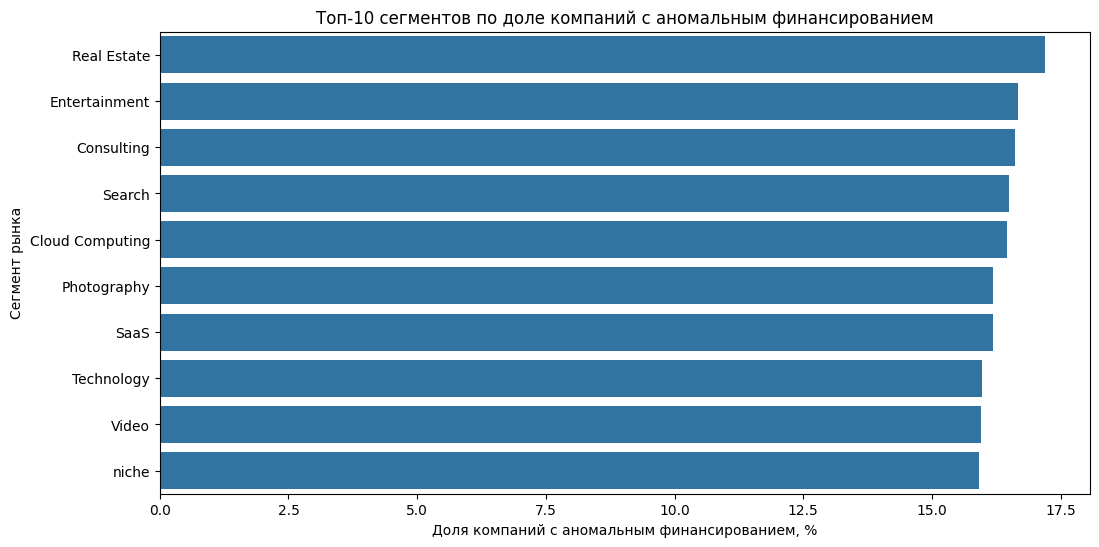

In [188]:
plt.figure(figsize=(12, 6))

top_outlier_markets = outlier_share_by_market.head(10)

sns.barplot(
    data=top_outlier_markets.reset_index(),
    x='outlier_share',
    y='market'
)

plt.title('Топ-10 сегментов по доле компаний с аномальным финансированием')
plt.xlabel('Доля компаний с аномальным финансированием, %')
plt.ylabel('Сегмент рынка')
plt.show()


# Вывод

Метод IQR, применённый отдельно внутри каждого сегмента рынка, позволил выявить 5 244 компании с аномальным объёмом финансирования — около 12,82% наблюдений после предобработки.

Наибольшая доля выбросов наблюдается в сегментах `Real Estate` (17,2%), `Entertainment` (16,7%), `Consulting` (16,6%), `Search` (16,5%) и `Cloud Computing` (16,4%). Это указывает на заметную неоднородность объёмов финансирования внутри отдельных направлений.

Расчёт границ отдельно по каждому сегменту позволяет учитывать различия в типичном масштабе инвестиций между рынками и снижает риск ошибочно считать аномальным значение, нормальное для более капиталоёмкого сегмента.


### 3.2. Определяем границы рассматриваемого периода и отбрасываем аномалии

Проверим полноту данных по годам. После этого исключим компании с аномальным финансированием и оставим только годы, в которых суммарно зафиксировано не менее 50 раундов финансирования.


In [189]:
df['mid_funding_year'] = df['mid_funding_at'].dt.year

rounds_by_year = (
    df.groupby('mid_funding_year')['funding_rounds']
    .sum()
    .sort_index()
)

rounds_by_year


,funding_rounds
mid_funding_year,
1921,1.0
1960,2.0
1979,1.0
1982,3.0
1983,1.0
1984,2.0
1985,3.0
1987,2.0
1989,1.0


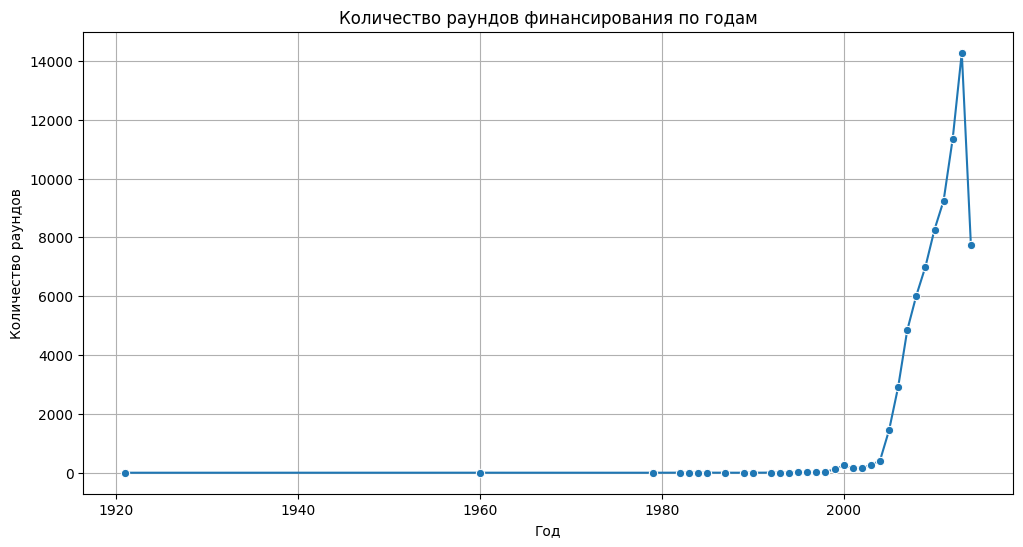

In [190]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=rounds_by_year.index,
    y=rounds_by_year.values,
    marker='o'
)

plt.title('Количество раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid(True)
plt.show()


In [191]:
# Дополнительно проверим полноту 2014 года по месяцам.
rounds_2014_by_month = (
    df[df['mid_funding_year'] == 2014]
    .groupby(df.loc[df['mid_funding_year'] == 2014, 'mid_funding_at'].dt.month)['funding_rounds']
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

rounds_2014_by_month


,funding_rounds
mid_funding_at,
1,893.0
2,715.0
3,810.0
4,807.0
5,761.0
6,900.0
7,779.0
8,636.0
9,595.0


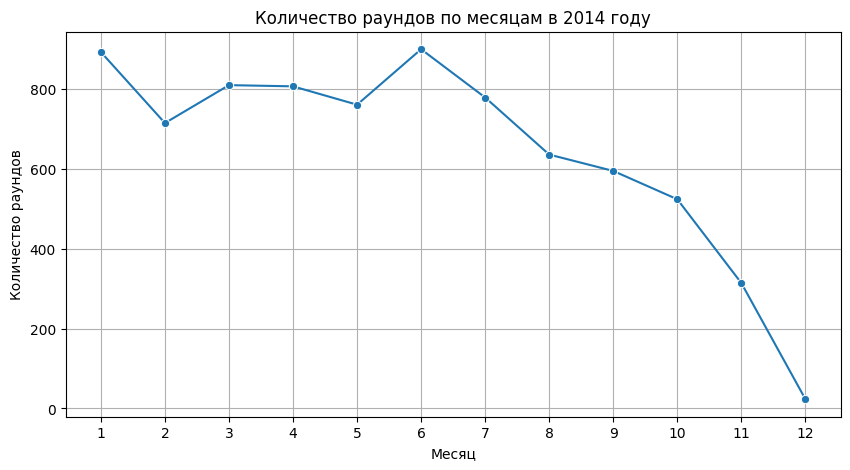

In [192]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=rounds_2014_by_month.index,
    y=rounds_2014_by_month.values,
    marker='o'
)

plt.title('Количество раундов по месяцам в 2014 году')
plt.xlabel('Месяц')
plt.ylabel('Количество раундов')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()


Количество раундов росло до 2013 года, а в 2014 году заметно снизилось. Проверка по месяцам помогает увидеть, что данные за конец 2014 года представлены хуже, поэтому 2014 год нельзя считать полностью сопоставимым с предыдущими годами. Это ограничение необходимо учитывать в интерпретации дальнейшей динамики.


In [193]:
df_clean = df[df['is_outlier'] == False].copy()

In [194]:
df_clean.shape

(35662, 44)

In [195]:
rounds_by_year_clean = (
    df_clean.groupby('mid_funding_year')['funding_rounds']
    .sum()
)

valid_years = rounds_by_year_clean[rounds_by_year_clean >= 50].index

valid_years

Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014],
      dtype='int32', name='mid_funding_year')

In [196]:
df_clean = df_clean[df_clean['mid_funding_year'].isin(valid_years)].copy()

In [197]:
df_clean.shape

(35588, 44)

### 3.3. Анализ типов финансирования по объёму и популярности

Сравним типы финансирования по двум характеристикам: суммарному объёму привлечённых средств и количеству компаний, у которых соответствующий тип финансирования встречается.


In [198]:
funding_types = [
    'seed',
    'venture',
    'equity_crowdfunding',
    'undisclosed',
    'convertible_note',
    'debt_financing',
    'angel',
    'grant',
    'private_equity',
    'post_ipo_equity',
    'post_ipo_debt',
    'secondary_market',
    'product_crowdfunding'
]

funding_volume = (
    df_clean[funding_types]
    .sum()
    .sort_values(ascending=False)
)

funding_volume


,0
venture,1.290922e+11
seed,9.431332e+09
debt_financing,8.178153e+09
private_equity,4.843109e+09
angel,2.481264e+09
undisclosed,2.100352e+09
grant,1.978849e+09
post_ipo_equity,1.946452e+09
convertible_note,5.660394e+08
post_ipo_debt,2.867183e+08


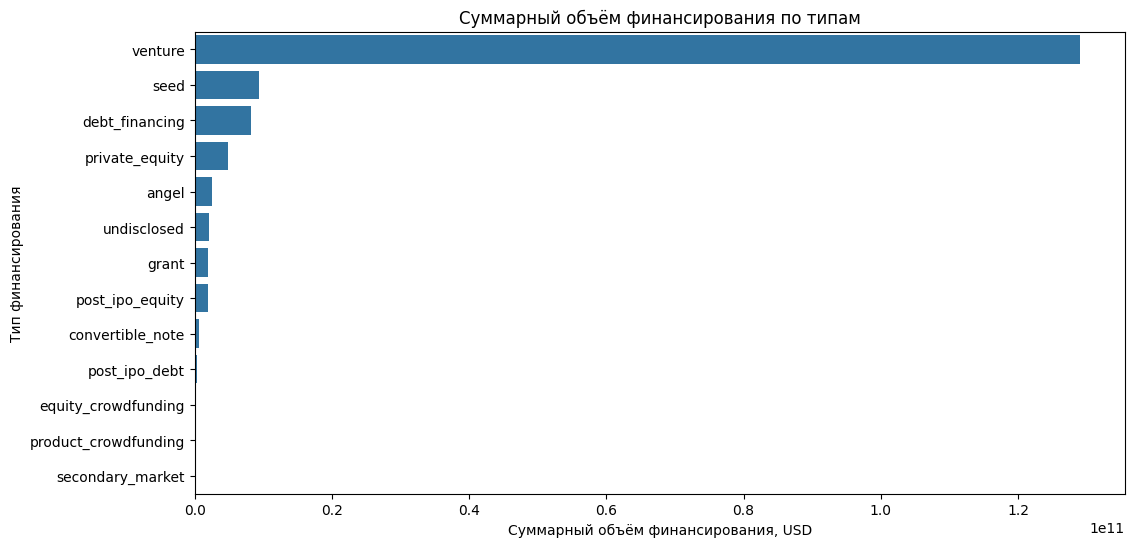

In [199]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=funding_volume.values,
    y=funding_volume.index
)

plt.title('Суммарный объём финансирования по типам')
plt.xlabel('Суммарный объём финансирования, USD')
plt.ylabel('Тип финансирования')
plt.show()


In [200]:
funding_popularity = (
    (df_clean[funding_types] > 0)
    .sum()
    .sort_values(ascending=False)
)

funding_popularity


,0
venture,18820
seed,13375
debt_financing,3265
angel,2937
grant,1003
undisclosed,813
private_equity,634
convertible_note,521
equity_crowdfunding,515
product_crowdfunding,204


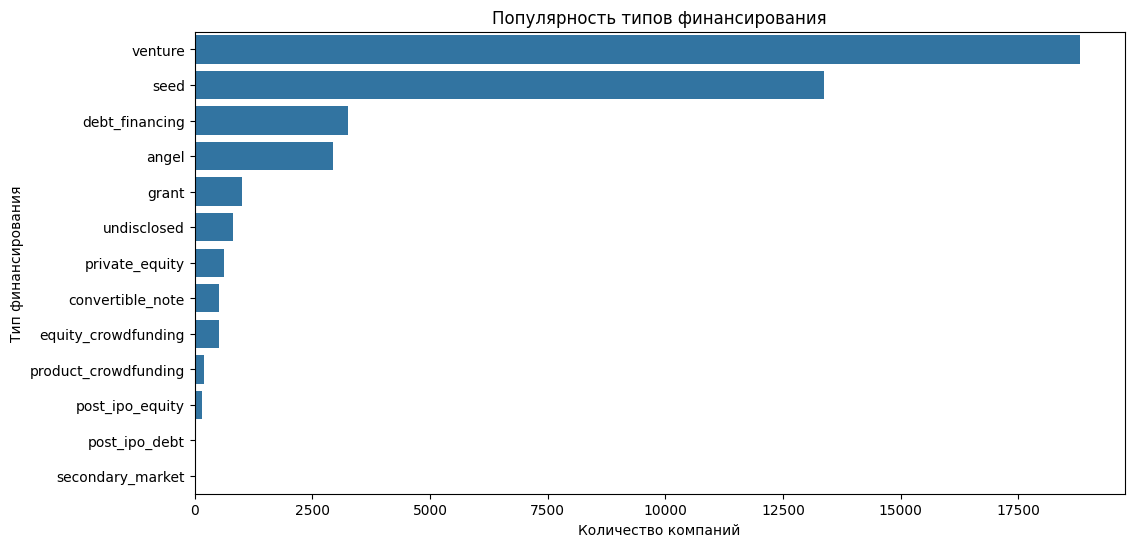

In [201]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=funding_popularity.values,
    y=funding_popularity.index
)

plt.title('Популярность типов финансирования')
plt.xlabel('Количество компаний')
plt.ylabel('Тип финансирования')
plt.show()

In [202]:
funding_comparison = pd.DataFrame({
    'volume': funding_volume,
    'popularity': funding_popularity
})

funding_comparison['avg_volume_per_company'] = (
    funding_comparison['volume']
    / funding_comparison['popularity'].replace(0, pd.NA)
)

funding_comparison.sort_values('volume', ascending=False)


,volume,popularity,avg_volume_per_company
venture,1.290922e+11,18820,6.859310e+06
seed,9.431332e+09,13375,7.051463e+05
debt_financing,8.178153e+09,3265,2.504794e+06
private_equity,4.843109e+09,634,7.638972e+06
angel,2.481264e+09,2937,8.448294e+05
undisclosed,2.100352e+09,813,2.583459e+06
grant,1.978849e+09,1003,1.972930e+06
post_ipo_equity,1.946452e+09,164,1.186861e+07
convertible_note,5.660394e+08,521,1.086448e+06
post_ipo_debt,2.867183e+08,27,1.061920e+07


## Вывод

Наибольший объём инвестиций приходится на venture financing, который значительно превосходит остальные типы финансирования. При этом именно венчурное финансирование является и наиболее распространённым способом привлечения средств. Посевное финансирование (seed) также широко используется компаниями, однако объём привлекаемых средств существенно ниже. В свою очередь private equity и post IPO equity встречаются значительно реже, но характеризуются крупными объёмами финансирования одной сделки.

Построим суммарные объёмы возвратов по типам финансирования на основе дополнительного датасета. Значения в `returns` заданы в миллионах долларов.


In [203]:
funding_comparison = pd.DataFrame({
    'volume': funding_volume,
    'popularity': funding_popularity
})

funding_comparison.sort_values('volume', ascending=False)

,volume,popularity
venture,1.290922e+11,18820
seed,9.431332e+09,13375
debt_financing,8.178153e+09,3265
private_equity,4.843109e+09,634
angel,2.481264e+09,2937
undisclosed,2.100352e+09,813
grant,1.978849e+09,1003
post_ipo_equity,1.946452e+09,164
convertible_note,5.660394e+08,521
post_ipo_debt,2.867183e+08,27


In [204]:
returns_volume = returns[funding_types].sum().sort_values(ascending=False)

returns_volume

,0
venture,40578.62
debt_financing,4734.85
private_equity,3587.33
seed,2382.24
angel,1509.23
post_ipo_equity,1104.96
undisclosed,730.88
post_ipo_debt,91.03
convertible_note,34.79
secondary_market,5.20


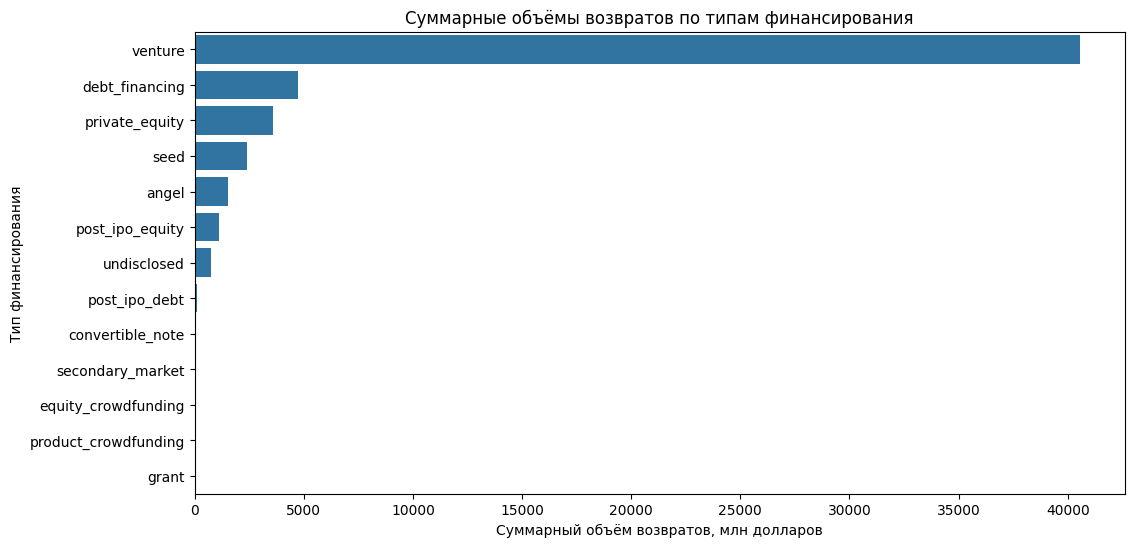

In [205]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=returns_volume.values,
    y=returns_volume.index
)

plt.title('Суммарные объёмы возвратов по типам финансирования')
plt.xlabel('Суммарный объём возвратов, млн долларов')
plt.ylabel('Тип финансирования')
plt.show()

## Вывод

Наибольший абсолютный объём возвращённых средств приходится на `venture financing`, который заметно опережает остальные типы финансирования. Высокие абсолютные значения также наблюдаются у `debt_financing` и `private_equity`, тогда как по грантам и краудфандинговым инструментам возвраты значительно ниже.

При этом абсолютный объём возвратов нельзя напрямую интерпретировать как доходность или эффективность типа финансирования: он во многом зависит от исходного масштаба вложенных средств. Поэтому далее возвраты рассматриваются и в нормированном виде.


## Шаг 4. Анализ динамики

### 4.1. Динамика предоставления финансирования по годам

Рассчитаем для каждой компании средний объём одного раунда, затем посмотрим на медианный размер раунда по годам и на суммарное количество раундов.


In [206]:
df_clean['avg_round_funding'] = (
    df_clean['funding_total_usd']
    / df_clean['funding_rounds']
)

df_clean = df_clean[
    (df_clean['funding_rounds'] > 0)
    & (df_clean['avg_round_funding'].notna())
].copy()

df_clean[
    ['funding_total_usd', 'funding_rounds', 'avg_round_funding']
].head()


,funding_total_usd,funding_rounds,avg_round_funding
1,2000000.0,1.0,2.000000e+06
2,9000000.0,1.0,9.000000e+06
3,7700000.0,3.0,2.566667e+06
4,540000.0,1.0,5.400000e+05
7,8700000.0,1.0,8.700000e+06


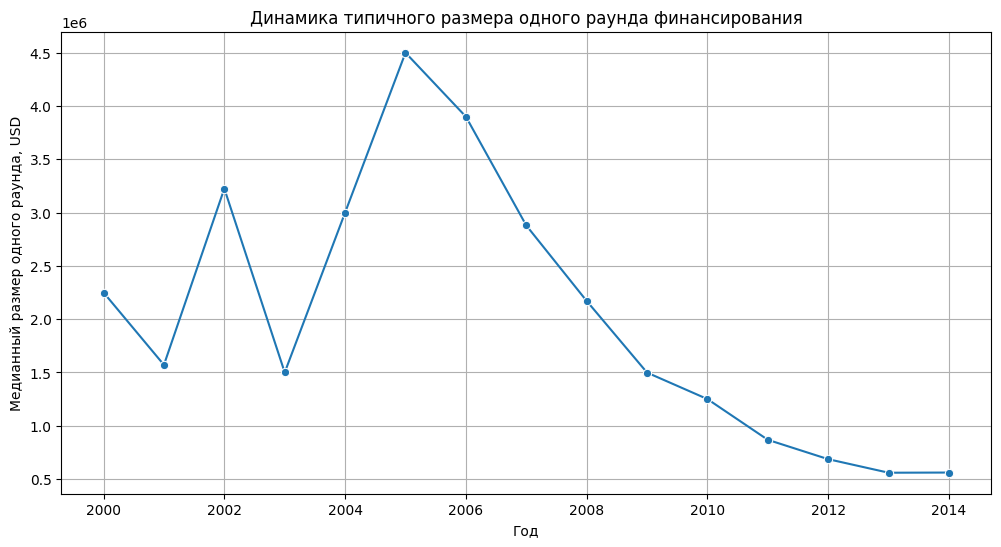

In [207]:
avg_round_by_year = (
    df_clean.groupby('mid_funding_year')['avg_round_funding']
    .median()
    .sort_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=avg_round_by_year.index,
    y=avg_round_by_year.values,
    marker='o'
)

plt.title('Динамика типичного размера одного раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Медианный размер одного раунда, USD')
plt.grid(True)
plt.show()


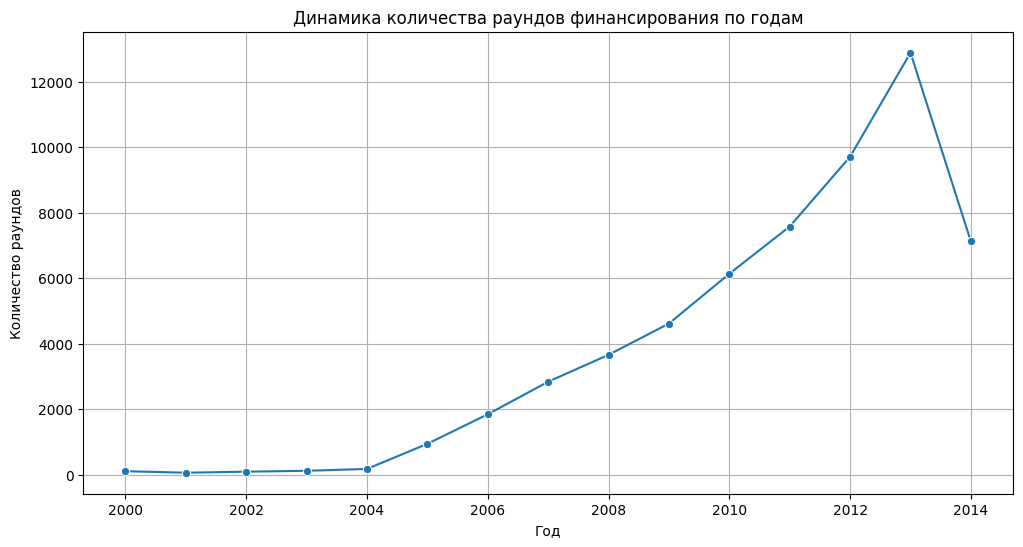

In [208]:
rounds_by_year_final = (
    df_clean.groupby('mid_funding_year')['funding_rounds']
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=rounds_by_year_final.index,
    y=rounds_by_year_final.values,
    marker='o'
)

plt.title('Динамика количества раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid(True)
plt.show()


In [209]:
max_avg_round_year = avg_round_by_year.idxmax()
max_avg_round_value = avg_round_by_year.max()

print(
    f'Максимальный типичный размер одного раунда был в '
    f'{max_avg_round_year} году: {max_avg_round_value:,.0f} USD.'
)

comparison_2013_2014 = pd.DataFrame({
    'median_round_usd': avg_round_by_year.loc[2013:2014],
    'rounds': rounds_by_year_final.loc[2013:2014]
})

comparison_2013_2014


Максимальный типичный размер одного раунда был в 2005 году: 4,500,000 USD.


,median_round_usd,rounds
mid_funding_year,,
2013,559000.0,12880.0
2014,560625.0,7122.0


## Вывод

Максимальный медианный размер одного раунда наблюдается в 2005 году — около 4,5 млн долларов. После 2005 года типичный размер раунда в целом снижается, тогда как число раундов растёт вплоть до 2013 года. Это может отражать расширение рынка стартапов: финансирование стало доступно большему числу компаний и чаще распределялось между меньшими по размеру раундами.

В 2014 году количество раундов резко снижается относительно 2013 года, а медианный размер раунда остаётся примерно на прежнем уровне. С учётом выявленной неполноты данных за 2014 год падение количества раундов нельзя безоговорочно трактовать как реальное сокращение рыночной активности.


### 4.2. Динамика общего финансирования по массовым сегментам, выросшим в 2014 году

Составим сводную таблицу суммарного финансирования по годам и массовым сегментам. Средние и нишевые категории исключим, после чего оставим сегменты, у которых значение 2014 года выше значения 2013 года.


In [210]:
mass_df = df_clean[
    ~df_clean['market'].isin(['mid', 'niche', 'unknown'])
].copy()

In [211]:
funding_pivot = mass_df.pivot_table(
    index='mid_funding_year',
    columns='market',
    values='funding_total_usd',
    aggfunc='sum'
)

funding_pivot.head()

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,...,Semiconductors,Social Media,Social Network Media,Software,Sports,Startups,Technology,Travel,Video,Web Hosting
mid_funding_year,,,,,,,,,,,,,,,,,,,,,
2000,14470000.0,14822803.0,NaN,NaN,NaN,NaN,NaN,11500000.0,4500000.0,1000000.0,...,NaN,NaN,NaN,31732640.0,NaN,NaN,NaN,50230.0,NaN,95343090.0
2001,8778321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305000.0,...,101727992.0,650000.0,NaN,27811352.0,NaN,NaN,22160000.0,NaN,NaN,15000000.0
2002,24500000.0,7500000.0,NaN,NaN,NaN,NaN,34390435.0,NaN,NaN,4650000.0,...,NaN,NaN,NaN,101026395.0,200000.0,NaN,11000000.0,NaN,NaN,NaN
2003,10500000.0,3840000.0,NaN,4530000.0,NaN,85531178.0,50352939.0,NaN,NaN,2550000.0,...,28000000.0,5000.0,NaN,66086037.0,NaN,NaN,NaN,NaN,5000000.0,NaN
2004,6000000.0,3000000.0,NaN,NaN,NaN,97184859.0,50427954.0,NaN,NaN,27050000.0,...,88782797.0,6850000.0,NaN,140823795.0,NaN,NaN,1750000.0,10230000.0,14704000.0,27000000.0


In [212]:
growing_markets_2014 = funding_pivot.columns[
    (funding_pivot.loc[2014] > funding_pivot.loc[2013])
]

growing_markets_2014

Index(['Apps', 'Big Data', 'Design', 'Internet', 'Manufacturing', 'Medical',
       'Real Estate', 'SaaS', 'Startups', 'Technology'],
      dtype='object', name='market')

In [213]:
growing_funding_pivot = funding_pivot[growing_markets_2014]

growing_funding_pivot.head()

market,Apps,Big Data,Design,Internet,Manufacturing,Medical,Real Estate,SaaS,Startups,Technology
mid_funding_year,,,,,,,,,,
2000,NaN,NaN,NaN,10000000.0,56659310.0,24000000.0,2500000.0,NaN,NaN,NaN
2001,NaN,NaN,NaN,NaN,2368582.0,NaN,NaN,NaN,NaN,22160000.0
2002,NaN,NaN,NaN,1100000.0,NaN,NaN,5275000.0,2000000.0,NaN,11000000.0
2003,NaN,NaN,NaN,NaN,4269608.0,NaN,6292200.0,NaN,NaN,NaN
2004,NaN,NaN,NaN,10500000.0,3000000.0,NaN,NaN,NaN,NaN,1750000.0


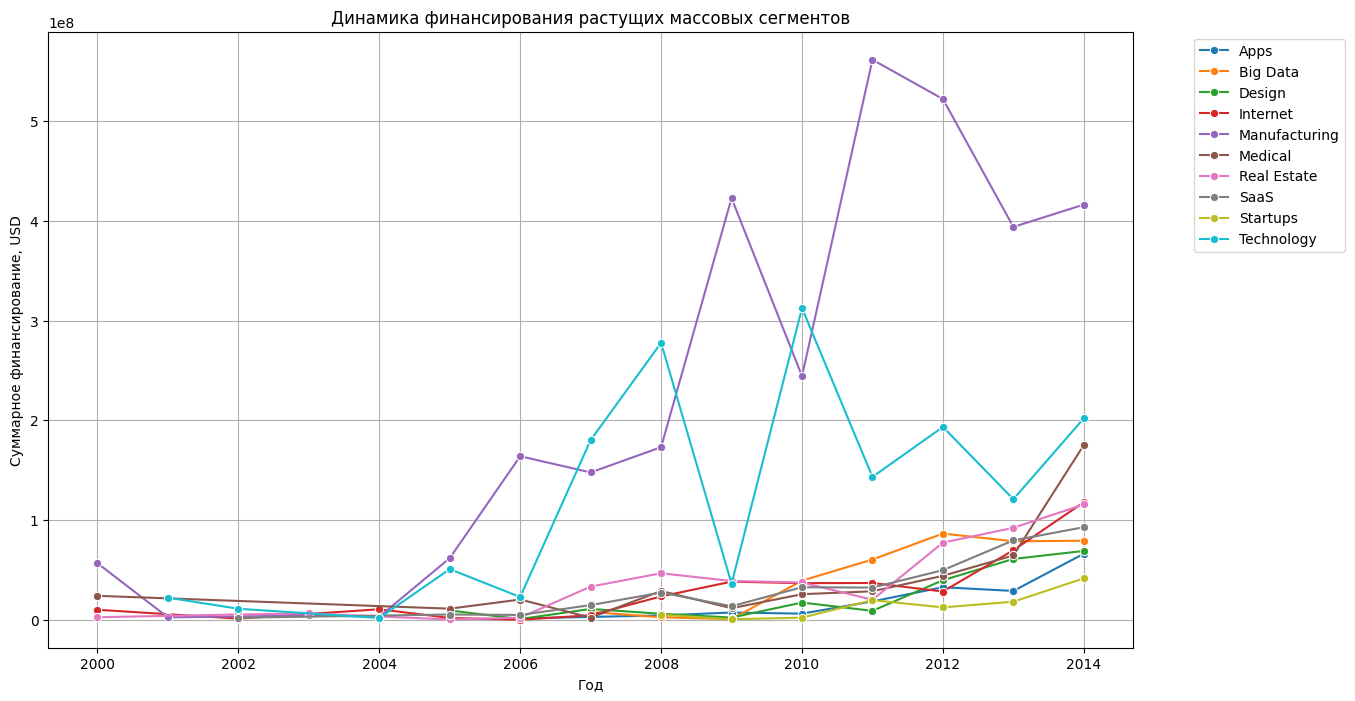

In [214]:
plt.figure(figsize=(14, 8))

for market in growing_funding_pivot.columns:
    sns.lineplot(
        x=growing_funding_pivot.index,
        y=growing_funding_pivot[market],
        marker='o',
        label=market
    )

plt.title('Динамика финансирования растущих массовых сегментов')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование, USD')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Вывод

В 2014 году рост суммарного финансирования по сравнению с 2013 годом показали следующие массовые сегменты: Apps, Big Data, Design, Internet, Manufacturing, Medical, Real Estate, SaaS, Startups и Technology.

Наибольший абсолютный прирост финансирования наблюдается в сегментах Medical — примерно на 110,8 млн долларов, Technology — примерно на 81,1 млн долларов и Internet — примерно на 48,1 млн долларов. Также заметный рост показали Apps и Startups.

При этом сегмент Manufacturing остаётся одним из крупнейших по общему объёму финансирования, но его прирост в 2014 году относительно 2013 года был сравнительно небольшим.

Таким образом, среди рассматриваемых массовых сегментов наиболее выраженную положительную динамику показали Medical, Technology и Internet. Однако результаты за 2014 год следует интерпретировать осторожно, поскольку ранее было установлено, что данные за этот год представлены не полностью.

In [215]:
growth_2014 = pd.DataFrame({
    'funding_2013': funding_pivot.loc[2013, growing_markets_2014],
    'funding_2014': funding_pivot.loc[2014, growing_markets_2014]
})

growth_2014['growth_abs'] = growth_2014['funding_2014'] - growth_2014['funding_2013']
growth_2014['growth_percent'] = growth_2014['growth_abs'] / growth_2014['funding_2013'] * 100

growth_2014.sort_values('growth_abs', ascending=False).head(10)

,funding_2013,funding_2014,growth_abs,growth_percent
market,,,,
Medical,64469424.0,175236064.0,110766640.0,171.812672
Technology,120873887.0,202018937.0,81145050.0,67.131994
Internet,69732096.0,117830756.0,48098660.0,68.976358
Apps,28868621.0,66237730.0,37369109.0,129.445424
Startups,18080552.0,41501837.0,23421285.0,129.538551
Real Estate,92207655.0,115567364.0,23359709.0,25.333807
Manufacturing,393936634.0,416332314.0,22395680.0,5.685097
SaaS,79576613.0,92807752.0,13231139.0,16.626919
Design,60958835.0,68988516.0,8029681.0,13.172301


### 4.3. Годовая динамика доли возвращённых средств по типам финансирования

Для каждого года и типа финансирования рассчитаем отношение возвратов к привлечённым средствам. Возвраты переведём из миллионов долларов в доллары. Значения доли выше 1 будем считать неадекватными выбросами и заменим пропусками.


In [216]:
selected_funding_types = [
    'venture',
    'debt_financing',
    'private_equity',
    'seed',
    'angel'
]

In [217]:
funding_by_year_type = (
    df_clean
    .groupby('mid_funding_year')[selected_funding_types]
    .sum()
)

funding_by_year_type.head()

,venture,debt_financing,private_equity,seed,angel
mid_funding_year,,,,,
2000,327962152.0,14000000.0,0.0,16759140.0,24086333.0
2001,217519117.0,5829217.0,0.0,2667675.0,1000000.0
2002,306940622.0,15309671.0,7500000.0,10465192.0,3000000.0
2003,372234425.0,1050000.0,0.0,15318355.0,5629661.0
2004,664150451.0,30816623.0,0.0,18104728.0,11013741.0


In [218]:
returns_selected = returns[selected_funding_types] * 1_000_000

In [219]:
returns_selected.head()

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,55400000.0,8660000.0,0.0,16700000.0,6430000.0
2001,23490000.0,4490000.0,0.0,2880000.0,1180000.0
2002,209420000.0,3420000.0,1510000.0,6590000.0,3410000.0
2003,233860000.0,1090000.0,1620000.0,7740000.0,3410000.0
2004,555900000.0,13550000.0,2190000.0,9930000.0,9180000.0


In [220]:
common_years = funding_by_year_type.index.intersection(returns_selected.index)

common_years

Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014],
      dtype='int32')

In [221]:
funding_common = funding_by_year_type.loc[common_years]
returns_common = returns_selected.loc[common_years]

In [222]:
return_ratio = returns_common / (funding_common + 1e-60)

return_ratio.head()

,venture,debt_financing,private_equity,seed,angel
2000,0.168922,0.618571,0.000000e+00,0.996471,0.266956
2001,0.107991,0.770258,0.000000e+00,1.079592,1.180000
2002,0.682282,0.223388,2.013333e-01,0.629707,1.136667
2003,0.628260,1.038095,1.620000e+66,0.505276,0.605720
2004,0.837009,0.439698,2.190000e+66,0.548476,0.833504


In [223]:
return_ratio = return_ratio.mask(return_ratio > 1)

In [224]:
return_ratio.head()

,venture,debt_financing,private_equity,seed,angel
2000,0.168922,0.618571,0.000000,0.996471,0.266956
2001,0.107991,0.770258,0.000000,NaN,NaN
2002,0.682282,0.223388,0.201333,0.629707,NaN
2003,0.628260,NaN,NaN,0.505276,0.605720
2004,0.837009,0.439698,NaN,0.548476,0.833504


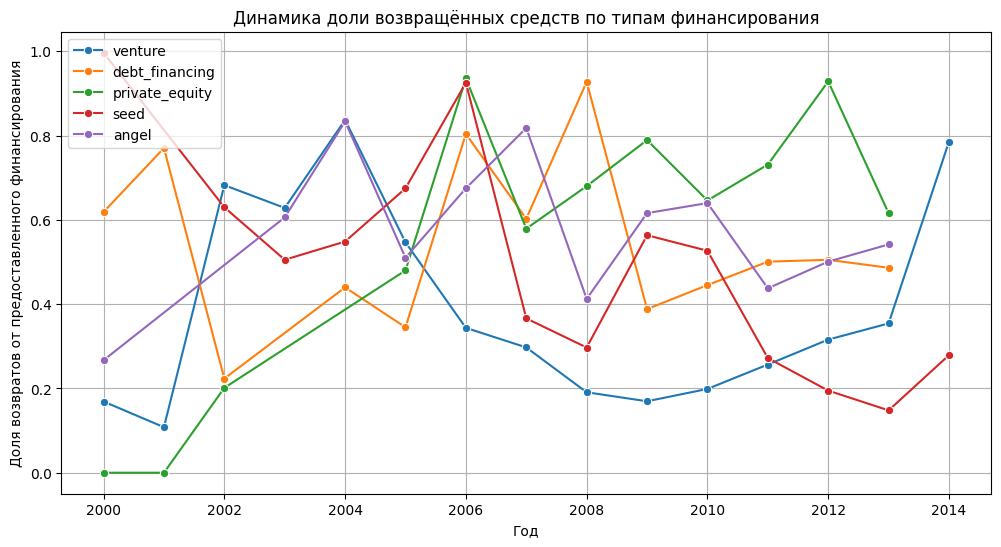

In [225]:
plt.figure(figsize=(12, 6))

for col in selected_funding_types:
    sns.lineplot(
        x=return_ratio.index,
        y=return_ratio[col],
        marker='o',
        label=col
    )

plt.title('Динамика доли возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возвратов от предоставленного финансирования')
plt.grid(True)
plt.legend()
plt.show()

## Вывод

Ни один из рассматриваемых типов финансирования не демонстрирует устойчивого монотонного роста нормированной доли возвратов на всём рассматриваемом периоде.

У `venture` ряд наблюдений наиболее непрерывный, однако показатель заметно меняется по годам. Для `seed` и `angel` также характерны выраженные колебания, а у `private_equity` часть значений была исключена как аномальная.

Поэтому рост или снижение нормированной доли возвратов нельзя напрямую трактовать как изменение эффективности конкретного типа финансирования. Рассчитанный показатель не является полноценной ROI-метрикой, поскольку финансирование и возвраты агрегированы по календарным годам и не связаны между собой на уровне конкретных инвестиций.


## Шаг 5. Итоговый вывод и рекомендации

В ходе проекта были выполнены следующие этапы:

- проведено первичное знакомство с основным и дополнительным датасетами;
- очищены названия столбцов, обработаны типы данных, пропуски и дубликаты;
- заполнен `mid_funding_at`, а записи без пригодных данных о финансировании исключены;
- компании сгруппированы по длительности привлечения финансирования;
- сегменты рынка разделены на массовые, средние и нишевые, после чего средние и нишевые категории укрупнены;
- выбросы в `funding_total_usd` определены методом IQR отдельно по сегментам;
- установлен период с достаточным количеством раундов финансирования и выявлена неполнота данных за 2014 год;
- проанализированы объёмы, распространённость и возвраты различных типов финансирования;
- исследована динамика размера одного раунда, количества раундов и суммарного финансирования по сегментам.

### Основные результаты

Около 58,9% компаний получили только один раунд финансирования. При этом компании с периодом финансирования более одного года составляют около 30,0% выборки, но аккумулируют примерно 61,9% общего объёма привлечённых средств.

Рынок стартапов сильно фрагментирован по числу уникальных направлений, однако основная часть компаний сосредоточена в ограниченном числе массовых сегментов.

Метод IQR выявил 5 244 наблюдения с аномальным объёмом финансирования — около 12,82% данных после предобработки. Наибольшая доля выбросов наблюдается в `Real Estate`, `Entertainment`, `Consulting`, `Search` и `Cloud Computing`.

Среди типов финансирования особенно выделяется `venture`: этот тип лидирует и по распространённости, и по суммарному объёму финансирования. `Seed` также используется очень часто, но связан с меньшими объёмами привлечённых средств. Некоторые более редкие типы финансирования характеризуются крупными суммами на компанию.

Максимальный медианный размер одного раунда наблюдается в 2005 году — около 4,5 млн долларов. После этого типичный размер раунда в целом снижается, тогда как количество раундов растёт вплоть до 2013 года. Такая разнонаправленная динамика может быть связана с расширением рынка и распределением инвестиций между большим числом компаний.

В 2014 году рост суммарного финансирования относительно 2013 года показали `Apps`, `Big Data`, `Design`, `Internet`, `Manufacturing`, `Medical`, `Real Estate`, `SaaS`, `Startups` и `Technology`. Наибольший абсолютный прирост наблюдается у `Medical` — около 110,8 млн долларов, `Technology` — около 81,1 млн долларов и `Internet` — около 48,1 млн долларов.

В абсолютном выражении наибольший объём возвратов приходится на `venture`. Однако нормированная доля возвратов заметно колеблется по годам, и ни один из рассматриваемых типов финансирования не показывает устойчивого монотонного роста на всём периоде. Кроме того, рассчитанный показатель нельзя считать полноценной метрикой ROI, поскольку возвраты не связаны с конкретными инвестиционными когортами.

### Рекомендация в контексте 2015 года

На основе результатов исследования для дальнейшего инвестиционного анализа можно в первую очередь рассмотреть сочетание **`Medical` + `venture`**.

Сегмент `Medical` показал крупнейший абсолютный прирост суммарного финансирования среди массовых сегментов, выросших в 2014 году. `Venture` при этом является наиболее масштабным и распространённым типом финансирования в рассматриваемых данных.

Однако эту рекомендацию следует рассматривать как направление для дальнейшего анализа, а не как готовое инвестиционное решение. Данные за 2014 год представлены неполно, а агрегированный характер информации о возвратах не позволяет напрямую оценить фактическую доходность отдельных инвестиций. Перед принятием решения необходим дополнительный анализ конкретных компаний, рисков, стадий развития и инвестиционного горизонта.
